# Split Analysis

Explore 80/20 train/test split quality on `data/challenge_train.csv`.  
Edit the **Config** cell below, then run all cells (`Kernel → Restart & Run All`).

Supported `SPLIT_TYPE` values:
- `"scaffold"` — Bemis-Murcko scaffold split (default, most stringent)
- `"random"` — random shuffle split (IID baseline)
- `"cluster_butina"` — Butina clustering; tune `BUTINA_CUTOFF`
- `"cluster_kmeans"` — k-means clustering; tune `K_CLUSTERS`
- `"cluster_bemis_murcko"` — Bemis-Murcko cluster split


In [9]:
# ── Config ─────────────────────────────────────────────────────────────────────
# Edit this cell to explore different splits.

SPLIT_TYPE = "random"  # scaffold | random | cluster_butina | cluster_kmeans | cluster_bemis_murcko
TEST_SIZE = 0.2  # fraction held out as test set
RANDOM_SEED = 43  # random state for reproducibility

# Cluster-split-specific parameters (ignored when not relevant)
BUTINA_CUTOFF = 0.65  # Tanimoto distance threshold for cluster_butina (0 < x < 1)
K_CLUSTERS = 10  # number of clusters for cluster_kmeans

# Data
DATA_PATH = "data/challenge_train.csv"
SMILES_COL = "SMILES"
ACTIVITY_COL = "pEC50"

# DATA_PATH = "data/ChEMBL_permissive_CYP3A4_CHEMBL340_aggregated.parquet"
# SMILES_COL = "OPENADMET_CANONICAL_SMILES"
# ACTIVITY_COL = "pchembl_value_median"

# DATA_PATH = "data/asap_potency.csv"
# SMILES_COL = "CXSMILES"
# ACTIVITY_COL = "pIC50 (SARS-CoV-2 Mpro)"

HIT_THRESHOLD = 6.3  # pEC50 >= this value → "hit"

# TMAP output
TMAP_OUTPUT_NAME = "split_analysis_tmap"
TMAP_OUTPUT_PATH = "results/"

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
import os

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from openadmet.models.split.cluster import ClusterSplitter
from openadmet.models.split.scaffold import ScaffoldSplitter
from openadmet.models.split.sklearn import ShuffleSplitter

from src.helpers import smiles_to_tmap
from src.plots import plot_tmap_faerun_partition

In [3]:
# ── Load data ──────────────────────────────────────────────────────────────────
if DATA_PATH.endswith(".csv"):
    df = pd.read_csv(DATA_PATH)
elif DATA_PATH.endswith(".parquet"):
    df = pd.read_parquet(DATA_PATH)

print(f"Loaded {len(df):,} compounds from {DATA_PATH}")
df.head(3)

Loaded 4,140 compounds from data/challenge_train.csv


,SMILES,pEC50
0,CC1C2CCCCC2CN1C(=O)C1=CC(F)=CC2=C1CNCC2,5.27
1,CN(C(=O)C1=CC=CC=C1SCC(=O)N1CCC2=CC=CC=C21)C1C...,5.08
2,O=C(C1CCCC1)N1CC(S(=O)(=O)NC2CC2C2=C(F)C=CC=C2...,5.12


In [ ]:
if "ChEMBL" in DATA_PATH:
    # Filter to compounds with low pChembl value std (i.e. more reliable measurements)
    df = df.loc[df["pchembl_value_std"] < 0.3].reset_index(drop=True)
    print(f"Filtered to {len(df):,} compounds with pChembl value std < 0.3")
elif "asap" in DATA_PATH:
    print("Using predefined ASAP train/test split")
    SPLIT_TYPE = "predefined"
    df_train = df.loc[df["Set"] == "Train"].reset_index(drop=True)[
        [SMILES_COL, ACTIVITY_COL]
    ]
    df_test = df.loc[df["Set"] == "Test"].reset_index(drop=True)[
        [SMILES_COL, ACTIVITY_COL]
    ]

    df_train.columns = ["smiles", ACTIVITY_COL]
    df_test.columns = ["smiles", ACTIVITY_COL]
    cluster_index = None
    print(f"\nTrain: {len(df_train):,} compounds  |  Test: {len(df_test):,} compounds")


In [ ]:
# ── Split ──────────────────────────────────────────────────────────────────────
if SPLIT_TYPE != "predefined":
    _SPLITTER_MAP = {
        "scaffold": lambda: ScaffoldSplitter(
            train_size=1.0 - TEST_SIZE,
            val_size=0.0,
            test_size=TEST_SIZE,
            random_state=RANDOM_SEED,
        ),
        "random": lambda: ShuffleSplitter(
            train_size=1.0 - TEST_SIZE,
            val_size=0.0,
            test_size=TEST_SIZE,
            random_state=RANDOM_SEED,
        ),
        "cluster_butina": lambda: ClusterSplitter(
            train_size=1.0 - TEST_SIZE,
            val_size=0.0,
            test_size=TEST_SIZE,
            random_state=RANDOM_SEED,
            method="butina",
            butina_cutoff=BUTINA_CUTOFF,
        ),
        "cluster_kmeans": lambda: ClusterSplitter(
            train_size=1.0 - TEST_SIZE,
            val_size=0.0,
            test_size=TEST_SIZE,
            random_state=RANDOM_SEED,
            method="kmeans",
            k_clusters=K_CLUSTERS,
        ),
        "cluster_bemis_murcko": lambda: ClusterSplitter(
            train_size=1.0 - TEST_SIZE,
            val_size=0.0,
            test_size=TEST_SIZE,
            random_state=RANDOM_SEED,
            method="bemis-murcko",
        ),
    }

    if SPLIT_TYPE not in _SPLITTER_MAP:
        raise ValueError(
            f"Unknown SPLIT_TYPE={SPLIT_TYPE!r}. Choose from: {list(_SPLITTER_MAP)}"
        )

    splitter = _SPLITTER_MAP[SPLIT_TYPE]()
    print(
        f"Splitting with SPLIT_TYPE={SPLIT_TYPE!r}, TEST_SIZE={TEST_SIZE}, RANDOM_SEED={RANDOM_SEED} ..."
    )

    X_train, _, X_test, y_train, _, y_test, cluster_index = splitter.split(
        df[SMILES_COL], df[ACTIVITY_COL]
    )

    df_train = pd.DataFrame({"smiles": X_train, ACTIVITY_COL: y_train}).reset_index(
        drop=True
    )
    df_test = pd.DataFrame({"smiles": X_test, ACTIVITY_COL: y_test}).reset_index(
        drop=True
    )

    print(f"\nTrain: {len(df_train):,} compounds  |  Test: {len(df_test):,} compounds")
    if cluster_index is not None:
        from collections import Counter as _Counter

        _sizes = _Counter(cluster_index)
        print(
            f"Clusters: {len(_sizes):,}  |  Singleton clusters: {sum(1 for v in _sizes.values() if v == 1):,}"
        )


Splitting with SPLIT_TYPE='random', TEST_SIZE=0.2, RANDOM_SEED=43 ...

Train: 3,312 compounds  |  Test: 828 compounds


In [10]:
# ── Summary statistics ─────────────────────────────────────────────────────────
def _split_stats(df_split: pd.DataFrame, name: str) -> dict:
    n = len(df_split)
    n_hits = (df_split[ACTIVITY_COL] >= HIT_THRESHOLD).sum()
    return {
        "Split": name,
        "N compounds": n,
        f"N hits (≥{HIT_THRESHOLD})": int(n_hits),
        "Hit fraction": f"{n_hits / n:.1%}" if n > 0 else "—",
        "Mean pEC50": f"{df_split[ACTIVITY_COL].mean():.3f}",
        "Std pEC50": f"{df_split[ACTIVITY_COL].std():.3f}",
        "Min pEC50": f"{df_split[ACTIVITY_COL].min():.3f}",
        "Max pEC50": f"{df_split[ACTIVITY_COL].max():.3f}",
    }


stats_df = pd.DataFrame(
    [
        _split_stats(df_train, "Train"),
        _split_stats(df_test, "Test"),
        _split_stats(df, "Full dataset"),
    ]
).set_index("Split")

display(stats_df)

,N compounds,N hits (≥6.3),Hit fraction,Mean pEC50,Std pEC50,Min pEC50,Max pEC50
Split,,,,,,,
Train,3312,20,0.6%,4.302,1.137,1.620,7.549
Test,828,5,0.6%,4.394,1.055,1.610,6.855
Full dataset,4140,25,0.6%,4.321,1.122,1.610,7.549


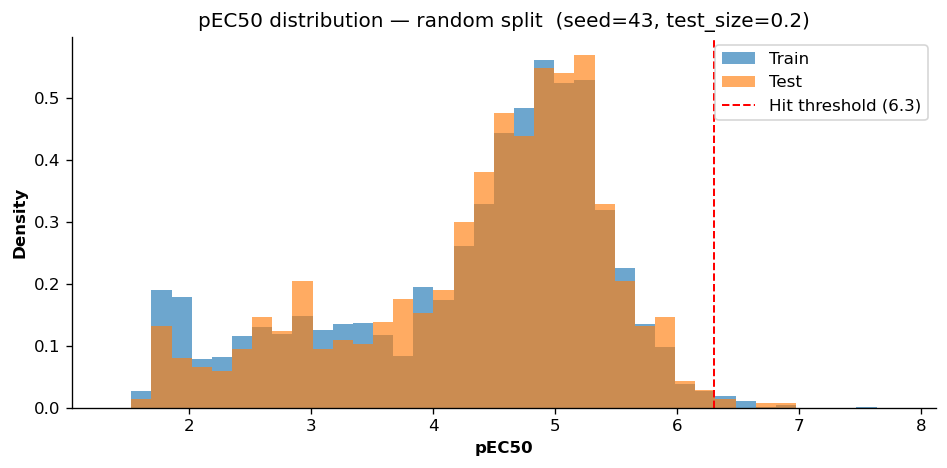

In [11]:
# ── pEC50 distribution ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

bins = np.linspace(
    df[ACTIVITY_COL].min() - 0.25,
    df[ACTIVITY_COL].max() + 0.25,
    40,
)

ax.hist(
    df_train[ACTIVITY_COL],
    bins=bins,
    alpha=0.65,
    color="#1f77b4",
    label="Train",
    density=True,
)
ax.hist(
    df_test[ACTIVITY_COL],
    bins=bins,
    alpha=0.65,
    color="#ff7f0e",
    label="Test",
    density=True,
)
ax.axvline(
    HIT_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"Hit threshold ({HIT_THRESHOLD})",
)

ax.set_xlabel("pEC50", fontweight="bold")
ax.set_ylabel("Density", fontweight="bold")
ax.set_title(
    f"pEC50 distribution — {SPLIT_TYPE} split  "
    f"(seed={RANDOM_SEED}, test_size={TEST_SIZE})"
)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# ── TMAP layout ────────────────────────────────────────────────────────────────
# Compute TMAP on ALL molecules (train + test concatenated).
# Partition labels:
#   0 = Train (non-singleton cluster)
#   1 = Test  (non-singleton cluster)
#   2 = Train (singleton cluster, i.e. cluster_index appears only once)
#   3 = Test  (singleton cluster)
# Falls back to 2-color mode (0/1) when cluster_index is None (scaffold/random split).

from collections import Counter

all_smiles = list(df_train["smiles"]) + list(df_test["smiles"])
n_train = len(df_train)

if cluster_index is not None:
    # Build smiles → cluster_id lookup from the original full dataset
    _smiles_to_cluster = dict(zip(df[SMILES_COL].values, cluster_index))
    _all_cluster_ids = [_smiles_to_cluster.get(smi, -1) for smi in all_smiles]
    _cluster_size = Counter(_all_cluster_ids)
    _is_singleton = [_cluster_size[cid] == 1 for cid in _all_cluster_ids]
else:
    _is_singleton = [False] * len(all_smiles)

partition_labels = np.array(
    [
        (2 if sing else 0) if i < n_train else (3 if sing else 1)
        for i, sing in enumerate(_is_singleton)
    ],
    dtype=int,
)

n_train_sing = (partition_labels == 2).sum()
n_test_sing = (partition_labels == 3).sum()
print(
    f"Train: {(partition_labels == 0).sum():,} non-singleton + {n_train_sing:,} singleton  "
    f"({n_train_sing / n_train:.1%} singletons)"
)
print(
    f"Test:  {(partition_labels == 1).sum():,} non-singleton + {n_test_sing:,} singleton  "
    f"({n_test_sing / len(df_test):.1%} singletons)"
)

print(
    f"\nComputing TMAP for {len(all_smiles):,} molecules (this may take a few minutes)..."
)
tmap_layout = smiles_to_tmap(
    all_smiles,
    fp_type="morgan",
    fp_size=1024,
    fp_radius=2,
    lsh_dim=128,
    k=50,
    sl_repeats=2,
    mmm_repeats=2,
    node_size=1,
)
print("TMAP layout computed.")


Train: 3,312 non-singleton + 0 singleton  (0.0% singletons)
Test:  828 non-singleton + 0 singleton  (0.0% singletons)

Computing TMAP for 4,140 molecules (this may take a few minutes)...
TMAP layout computed.


In [13]:
os.makedirs(TMAP_OUTPUT_PATH, exist_ok=True)

plot_tmap_faerun_partition(
    tmap_layout=tmap_layout,
    smiles_list=all_smiles,
    partition_labels=partition_labels,
    output_name=TMAP_OUTPUT_NAME,
    output_path=TMAP_OUTPUT_PATH,
    title=f"Train / Test Partition — {SPLIT_TYPE} (seed={RANDOM_SEED})",
)

/Users/smcolby/repos/active-learning-blogpost/results/split_analysis_tmap.html

In [14]:
# ── Nearest-neighbour Tanimoto similarities ───────────────────────────────────
# For each molecule, report the similarity to its MOST similar other molecule
# (nearest neighbour, non-identity).  This gives one value per compound rather
# than O(N²) pairwise values, making the distribution meaningful instead of
# dominated by the bulk of dissimilar pairs.
#
# Three groups:
#   within-train  — for each train mol, max sim to any *other* train mol
#   within-test   — for each test mol,  max sim to any *other* test mol
#   cross (test→train) — for each test mol, max sim to any train mol
#     (directly measures test-set novelty relative to training data)

import time
from rdkit import Chem
from rdkit.Chem import DataStructs, rdFingerprintGenerator

_fg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)


def _compute_fps(smiles_series):
    fps = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        fps.append(_fg.GetFingerprint(mol) if mol is not None else None)
    return [fp for fp in fps if fp is not None]


def _nn_similarities(fps_query, fps_db, exclude_self=False):
    """For each query fp, return its similarity to its nearest neighbour in fps_db.

    Parameters
    ----------
    fps_query, fps_db : list of RDKit fingerprints
    exclude_self : bool
        When True, fps_query and fps_db are the same list; masks the diagonal
        (self-similarity = 1.0) before taking the max.
    """
    nn_sims = []
    for i, fp in enumerate(fps_query):
        sims = np.array(
            DataStructs.BulkTanimotoSimilarity(fp, fps_db), dtype=np.float32
        )
        if exclude_self:
            sims[i] = -1.0  # mask self
        nn_sims.append(float(sims.max()))
    return np.array(nn_sims, dtype=np.float32)


print("Computing Morgan fingerprints...")
fps_train = _compute_fps(df_train["smiles"])
fps_test = _compute_fps(df_test["smiles"])

t0 = time.time()
print(f"  within-train NN ({len(fps_train)} mols)...")
nn_within_train = _nn_similarities(fps_train, fps_train, exclude_self=True)

print(f"  within-test  NN ({len(fps_test)} mols)...")
nn_within_test = _nn_similarities(fps_test, fps_test, exclude_self=True)

print(f"  cross NN test→train ({len(fps_test)} queries × {len(fps_train)} db)...")
nn_cross = _nn_similarities(fps_test, fps_train, exclude_self=False)

print(f"Done in {time.time() - t0:.1f}s.")


Computing Morgan fingerprints...
  within-train NN (3312 mols)...
  within-test  NN (828 mols)...
  cross NN test→train (828 queries × 3312 db)...
Done in 0.9s.


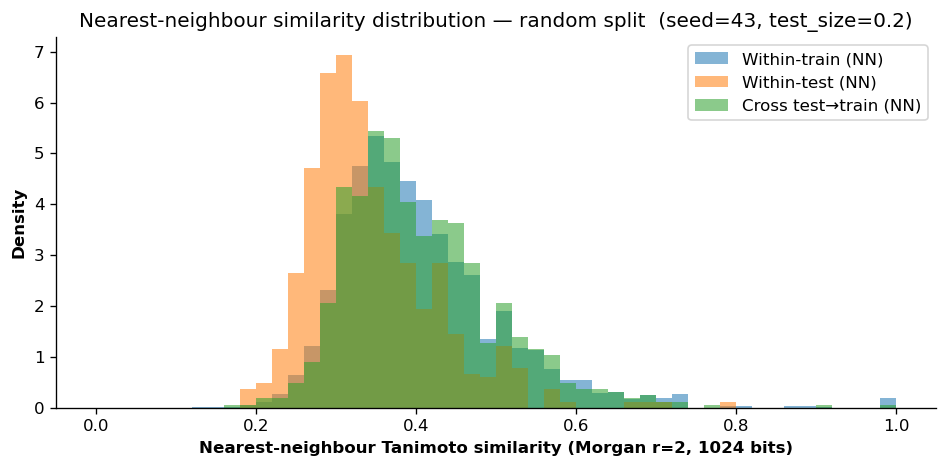

,N compounds,Mean NN sim,Median NN sim,Std,% > 0.4,% > 0.7
Group,,,,,,
Within-train (NN),"3,312",0.406,0.386,0.102,42.8%,1.6%
Within-test (NN),828,0.345,0.328,0.082,20.4%,0.5%
Cross test→train (NN),828,0.407,0.387,0.095,44.6%,0.8%


In [15]:
# ── Nearest-neighbour Tanimoto distribution plot + summary table ───────────────
_groups = {
    "Within-train (NN)": nn_within_train,
    "Within-test (NN)": nn_within_test,
    "Cross test→train (NN)": nn_cross,
}
_colors = {
    "Within-train (NN)": "#1f77b4",
    "Within-test (NN)": "#ff7f0e",
    "Cross test→train (NN)": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
bins = np.linspace(0, 1, 51)

for label, sims in _groups.items():
    ax.hist(
        sims, bins=bins, density=True, alpha=0.55, color=_colors[label], label=label
    )

ax.set_xlabel(
    "Nearest-neighbour Tanimoto similarity (Morgan r=2, 1024 bits)",
    fontweight="bold",
)
ax.set_ylabel("Density", fontweight="bold")
ax.set_title(
    f"Nearest-neighbour similarity distribution — {SPLIT_TYPE} split  "
    f"(seed={RANDOM_SEED}, test_size={TEST_SIZE})"
)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Summary statistics
rows = []
for label, sims in _groups.items():
    rows.append(
        {
            "Group": label,
            "N compounds": f"{len(sims):,}",
            "Mean NN sim": f"{sims.mean():.3f}",
            "Median NN sim": f"{float(np.median(sims)):.3f}",
            "Std": f"{sims.std():.3f}",
            "% > 0.4": f"{(sims > 0.4).mean():.1%}",
            "% > 0.7": f"{(sims > 0.7).mean():.1%}",
        }
    )

nn_stats = pd.DataFrame(rows).set_index("Group")
display(nn_stats)


Building lower-triangle distance matrix for 4,140 molecules...
  8,567,730 pairwise distances computed.
  threshold=0.05  clusters=4,133  singletons=4,126  (99.8%)
  threshold=0.10  clusters=4,131  singletons=4,123  (99.8%)
  threshold=0.15  clusters=4,128  singletons=4,119  (99.8%)
  threshold=0.20  clusters=4,127  singletons=4,117  (99.8%)
  threshold=0.25  clusters=4,124  singletons=4,111  (99.7%)
  threshold=0.30  clusters=4,101  singletons=4,068  (99.2%)
  threshold=0.35  clusters=4,073  singletons=4,017  (98.6%)
  threshold=0.40  clusters=4,020  singletons=3,926  (97.7%)
  threshold=0.45  clusters=3,921  singletons=3,757  (95.8%)
  threshold=0.50  clusters=3,702  singletons=3,405  (92.0%)
  threshold=0.55  clusters=3,390  singletons=2,934  (86.5%)
  threshold=0.60  clusters=2,883  singletons=2,286  (79.3%)
  threshold=0.65  clusters=2,195  singletons=1,521  (69.3%)
  threshold=0.70  clusters=1,330  singletons=760  (57.1%)
  threshold=0.75  clusters=603  singletons=275  (45.6%)
  

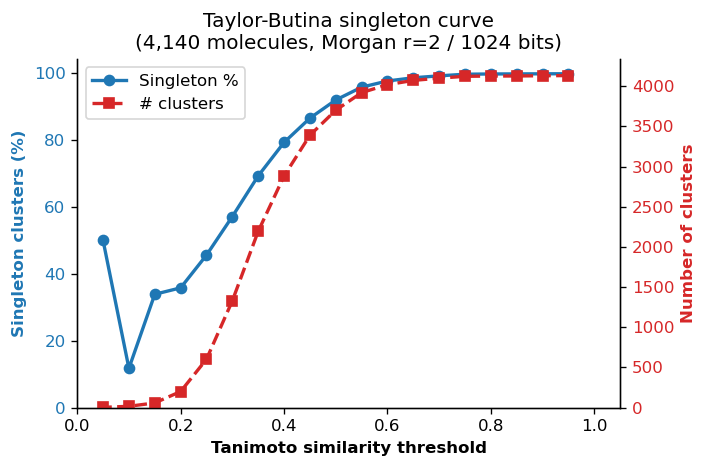

In [16]:
# ── Taylor-Butina singleton curve ─────────────────────────────────────────────
# Uses the Morgan fingerprints computed in the Tanimoto cell above.
# Builds the lower-triangle Tanimoto distance matrix for ALL molecules
# (train + test), then sweeps ClusterData over distance thresholds 0.3–0.8
# and plots the fraction of singleton clusters and total cluster count at each
# threshold.

from rdkit.ML.Cluster.Butina import ClusterData

fps_all = fps_train + fps_test
n_all = len(fps_all)

print(f"Building lower-triangle distance matrix for {n_all:,} molecules...")
dists = []
for i in range(1, n_all):
    sims = DataStructs.BulkTanimotoSimilarity(fps_all[i], fps_all[:i])
    dists.extend(1.0 - s for s in sims)
print(f"  {len(dists):,} pairwise distances computed.")

thresholds = np.arange(0.05, 1.0, 0.05)
singleton_pcts = []
n_clusters_list = []

for thresh in thresholds:
    clusters = ClusterData(dists, n_all, thresh, isDistData=True)
    n_singletons = sum(1 for c in clusters if len(c) == 1)
    pct = 100.0 * n_singletons / len(clusters)
    singleton_pcts.append(pct)
    n_clusters_list.append(len(clusters))
    print(
        f"  threshold={thresh:.2f}  clusters={len(clusters):,}  singletons={n_singletons:,}  ({pct:.1f}%)"
    )

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)

color_singleton = "#1f77b4"
color_clusters = "#d62728"

ax1.plot(
    1 - thresholds,
    singleton_pcts,
    marker="o",
    color=color_singleton,
    linewidth=2,
    label="Singleton %",
)
ax1.set_xlabel("Tanimoto similarity threshold", fontweight="bold")
ax1.set_ylabel("Singleton clusters (%)", color=color_singleton, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=color_singleton)
ax1.set_ylim(0, None)
ax1.set_xlim(0, 1.05)
ax1.spines[["top"]].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(
    1 - thresholds,
    n_clusters_list,
    marker="s",
    color=color_clusters,
    linewidth=2,
    linestyle="--",
    label="# clusters",
)
ax2.set_ylabel("Number of clusters", color=color_clusters, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=color_clusters)
ax2.spines[["top"]].set_visible(False)
ax2.set_ylim(0, None)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title(
    f"Taylor-Butina singleton curve\n({n_all:,} molecules, Morgan r=2 / 1024 bits)"
)
plt.tight_layout()
plt.show()


Computing Bemis-Murcko scaffolds for 4,140 molecules...

Summary
  Compounds          : 4,140
  Unique scaffolds   : 3,672  (88.7% of compounds)
  Singleton scaffolds: 3,527  (96.1% of scaffolds)


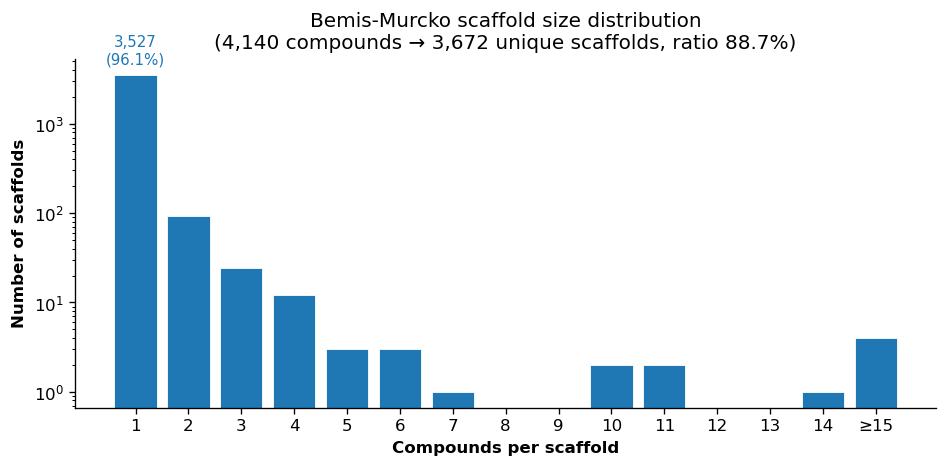

,Scaffold SMILES,# compounds
1,c1ccccc1,149
2,,30
3,O=C(Nc1ccccc1)c1ccccc1,17
4,O=C(NCc1ccccc1)c1ccccc1,15
5,c1ccncc1,14
6,O=S(=O)(Nc1ccccc1)c1ccccc1,11
7,c1ccc2[nH]ccc2c1,11
8,c1ccc(N2CCNCC2)cc1,10
9,c1ccc2ncccc2c1,10
10,C1COCCN1,7


In [17]:
# ── Bemis-Murcko scaffold diversity ───────────────────────────────────────────
# Tests the hypothesis that this dataset is so chemically diverse that the
# number of unique Bemis-Murcko scaffolds approaches the number of compounds.
# Uses all molecules in the full dataset (train + test).

from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter

all_smiles_full = list(df_train["smiles"]) + list(df_test["smiles"])
n_compounds = len(all_smiles_full)

print(f"Computing Bemis-Murcko scaffolds for {n_compounds:,} molecules...")
scaffolds = []
for smi in all_smiles_full:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        scaffolds.append(
            MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
        )
    else:
        scaffolds.append(None)

scaffold_counts = Counter(s for s in scaffolds if s is not None)
n_unique = len(scaffold_counts)
n_singletons = sum(1 for v in scaffold_counts.values() if v == 1)
ratio = n_unique / n_compounds

print(f"\nSummary")
print(f"  Compounds          : {n_compounds:,}")
print(f"  Unique scaffolds   : {n_unique:,}  ({ratio:.1%} of compounds)")
print(
    f"  Singleton scaffolds: {n_singletons:,}  ({n_singletons / n_unique:.1%} of scaffolds)"
)

# ── Plot: scaffold size distribution ──────────────────────────────────────────
size_counts = Counter(
    scaffold_counts.values()
)  # {n_members: n_scaffolds_with_that_many}
max_size = max(size_counts)
xs = list(range(1, min(max_size + 1, 16)))  # show sizes 1..15, group the rest
ys = [size_counts.get(x, 0) for x in xs]
if max_size >= 16:
    ys[-1] = sum(v for k, v in size_counts.items() if k >= 15)
    xs[-1] = 15  # last bar labelled ≥15

fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
bars = ax.bar(
    [str(x) if x < 15 else "≥15" for x in xs],
    ys,
    color="#1f77b4",
    edgecolor="white",
    linewidth=0.5,
)

# Annotate the singleton bar
ax.annotate(
    f"{ys[0]:,}\n({ys[0] / n_unique:.1%})",
    xy=(bars[0].get_x() + bars[0].get_width() / 2, ys[0]),
    xytext=(0, 6),
    textcoords="offset points",
    ha="center",
    fontsize=9,
    color="#1f77b4",
)

ax.set_xlabel("Compounds per scaffold", fontweight="bold")
ax.set_ylabel("Number of scaffolds", fontweight="bold")
ax.set_title(
    f"Bemis-Murcko scaffold size distribution\n"
    f"({n_compounds:,} compounds → {n_unique:,} unique scaffolds, ratio {ratio:.1%})"
)
ax.spines[["top", "right"]].set_visible(False)

ax.set_yscale("log")

plt.tight_layout()
plt.show()

# ── Top 10 most populated scaffolds ───────────────────────────────────────────
top10 = scaffold_counts.most_common(10)
top10_df = pd.DataFrame(top10, columns=["Scaffold SMILES", "# compounds"])
top10_df.index = top10_df.index + 1
display(top10_df)
